In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully")

Matplotlib is building the font cache; this may take a moment.


Libraries loaded successfully


In [2]:
train = pd.read_csv("../data/processed/train.csv")
validation = pd.read_csv("../data/processed/validation.csv")
test = pd.read_csv("../data/processed/test.csv")

print("Train shape:", train.shape)
print("Validation shape:", validation.shape)
print("Test shape:", test.shape)

Train shape: (121960, 60)
Validation shape: (26140, 60)
Test shape: (26140, 60)


In [3]:
train.head()

,reading_id,bin_id,timestamp,latitude,longitude,locality,collection_zone,area_type,bin_capacity_liters,bin_type,...,target_fill_level_3h_pct,target_fill_level_6h_pct,target_fill_level_12h_pct,target_fill_level_24h_pct,target_overflow_6h,historical_avg_fill_pct,historical_max_fill_pct,capacity_remaining_pct,fill_rate_24h_est_pct_per_hour,estimated_hours_to_full
0,R00000025,B0001,2025-08-02 00:00:00,10.018286,76.366415,East,Z4,School,970,Mixed,...,48.772378,48.949742,49.312072,49.795889,0,45.351036,53.639758,46.360242,0.555290,6.565710
1,R00000026,B0001,2025-08-02 01:00:00,10.018286,76.366415,East,Z4,School,970,Mixed,...,48.820229,48.953314,49.371376,49.795889,0,45.432093,53.639758,52.541475,0.114650,999.000000
2,R00000027,B0001,2025-08-02 02:00:00,10.018286,76.366415,East,Z4,School,970,Mixed,...,48.913702,48.991109,49.403639,49.816212,0,45.399837,53.639758,55.438811,0.130478,999.000000
3,R00000028,B0001,2025-08-02 03:00:00,10.018286,76.366415,East,Z4,School,970,Mixed,...,48.949742,49.060793,49.502493,49.843560,0,45.419847,53.639758,54.039891,0.130279,38.629748
4,R00000029,B0001,2025-08-02 04:00:00,10.018286,76.366415,East,Z4,School,970,Mixed,...,48.953314,49.115776,49.585038,49.891802,0,45.381212,53.639758,55.700569,0.005166,999.000000


In [4]:
train.columns.tolist()

['reading_id',
 'bin_id',
 'timestamp',
 'latitude',
 'longitude',
 'locality',
 'collection_zone',
 'area_type',
 'bin_capacity_liters',
 'bin_type',
 'service_window',
 'demand_multiplier',
 'sensor_fill_level_pct',
 'hours_since_collection',
 'temperature_c',
 'humidity_pct',
 'rainfall_mm',
 'weather_condition',
 'global_event',
 'is_holiday',
 'local_event',
 'sensor_anomaly',
 'previous_fill_1h_pct',
 'previous_fill_2h_pct',
 'previous_fill_3h_pct',
 'previous_fill_6h_pct',
 'previous_fill_12h_pct',
 'previous_fill_24h_pct',
 'fill_change_1h_pct',
 'fill_change_6h_pct',
 'fill_rate_1h_pct_per_hour',
 'fill_rate_6h_pct_per_hour',
 'avg_fill_6h_pct',
 'avg_fill_24h_pct',
 'avg_fill_7d_pct',
 'max_fill_24h_pct',
 'collection_count_7d',
 'day_of_week',
 'day_of_month',
 'month',
 'week_of_year',
 'hour',
 'is_weekend',
 'is_night',
 'hour_sin',
 'hour_cos',
 'dow_sin',
 'dow_cos',
 'month_sin',
 'month_cos',
 'target_fill_level_3h_pct',
 'target_fill_level_6h_pct',
 'target_fill_leve

In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 121960 entries, 0 to 121959
Data columns (total 60 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   reading_id                      121960 non-null  str    
 1   bin_id                          121960 non-null  str    
 2   timestamp                       121960 non-null  str    
 3   latitude                        121960 non-null  float64
 4   longitude                       121960 non-null  float64
 5   locality                        121960 non-null  str    
 6   collection_zone                 121960 non-null  str    
 7   area_type                       121960 non-null  str    
 8   bin_capacity_liters             121960 non-null  int64  
 9   bin_type                        121960 non-null  str    
 10  service_window                  121960 non-null  str    
 11  demand_multiplier               121960 non-null  float64
 12  sensor_fill_level_pct      

In [6]:
missing = train.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

global_event    117160
dtype: int64


In [7]:
print("Duplicate rows:", train.duplicated().sum())

Duplicate rows: 0


In [8]:
train["target_fill_level_6h_pct"].describe()

count    121960.000000
mean         46.281395
std          24.999086
min           3.686236
25%          25.690717
50%          42.936206
75%          63.328153
max         110.948864
Name: target_fill_level_6h_pct, dtype: float64

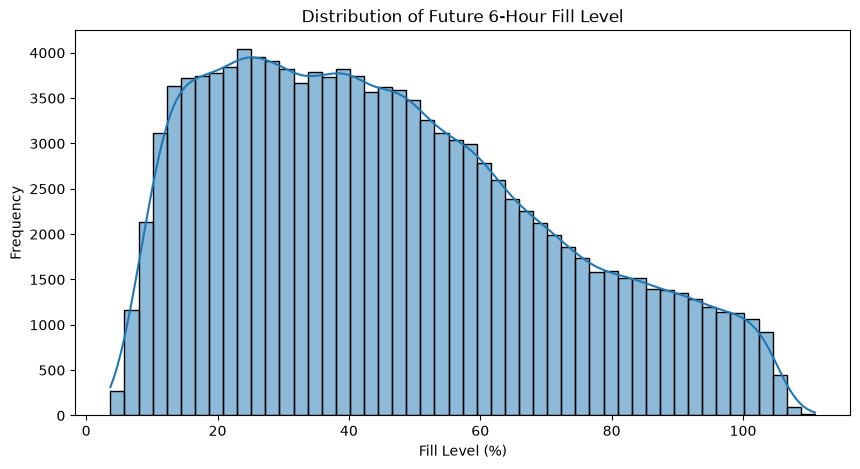

In [9]:
plt.figure(figsize=(10, 5))

sns.histplot(
    train["target_fill_level_6h_pct"],
    bins=50,
    kde=True
)

plt.title("Distribution of Future 6-Hour Fill Level")
plt.xlabel("Fill Level (%)")
plt.ylabel("Frequency")

plt.show()

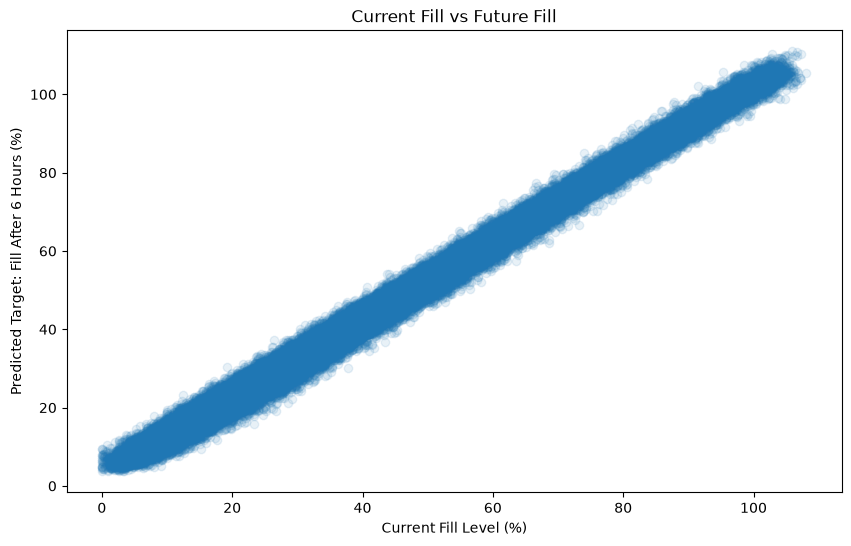

In [10]:
plt.figure(figsize=(10, 6))

plt.scatter(
    train["sensor_fill_level_pct"],
    train["target_fill_level_6h_pct"],
    alpha=0.1
)

plt.xlabel("Current Fill Level (%)")
plt.ylabel("Predicted Target: Fill After 6 Hours (%)")
plt.title("Current Fill vs Future Fill")

plt.show()

In [11]:
train["area_type"].value_counts()

area_type
Residential    30490
Commercial     30490
School         18294
Industrial     18294
Market         12196
Public_Park     6098
Hospital        6098
Name: count, dtype: int64

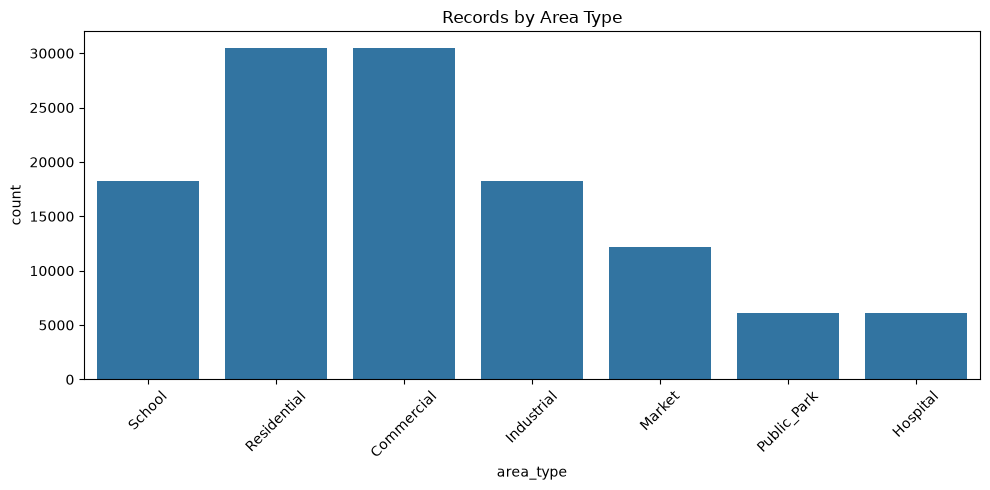

In [12]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=train,
    x="area_type"
)

plt.xticks(rotation=45)
plt.title("Records by Area Type")
plt.tight_layout()

plt.show()

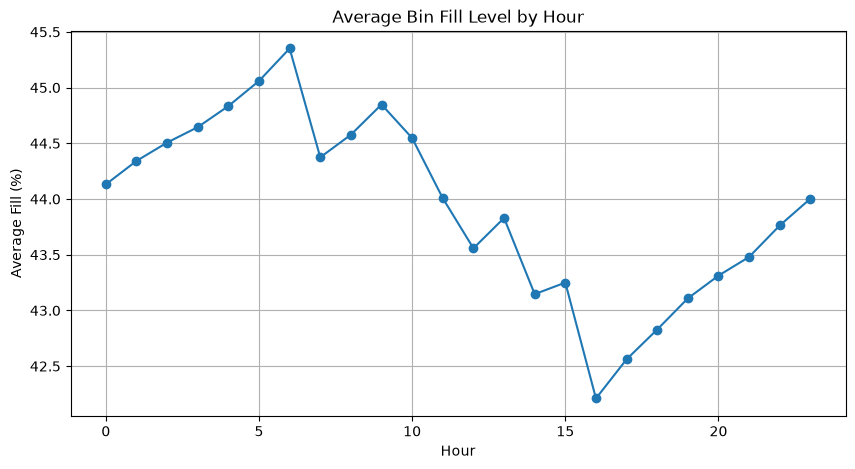

In [13]:
hourly_fill = (
    train
    .groupby("hour")["sensor_fill_level_pct"]
    .mean()
)

plt.figure(figsize=(10, 5))

hourly_fill.plot(marker="o")

plt.title("Average Bin Fill Level by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Fill (%)")
plt.grid()

plt.show()

In [14]:
area_fill = (
    train
    .groupby("area_type")["sensor_fill_level_pct"]
    .mean()
    .sort_values(ascending=False)
)

print(area_fill)

area_type
Market         52.205222
Hospital       47.169719
Commercial     46.661904
School         41.817465
Public_Park    41.627812
Residential    41.599161
Industrial     39.532937
Name: sensor_fill_level_pct, dtype: float64


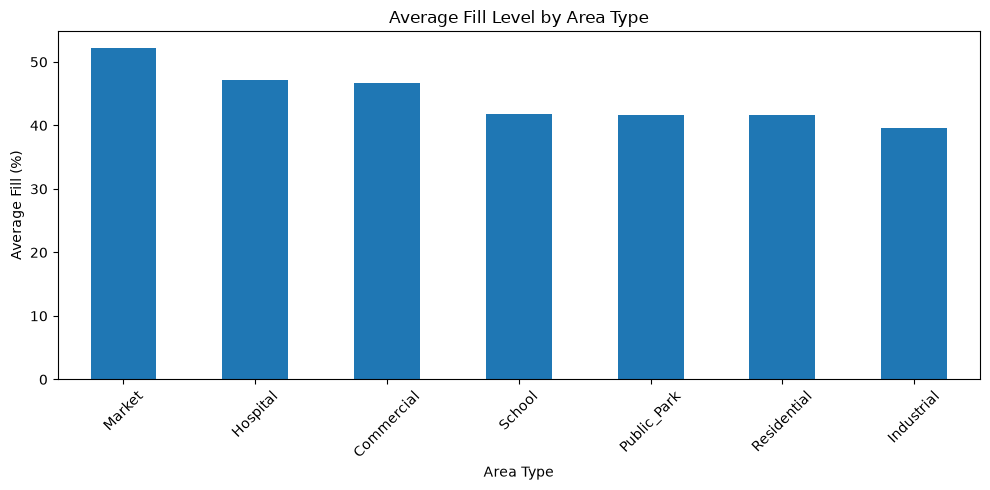

In [15]:
plt.figure(figsize=(10, 5))

area_fill.plot(kind="bar")

plt.title("Average Fill Level by Area Type")
plt.xlabel("Area Type")
plt.ylabel("Average Fill (%)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()